# 🌿 MBMU Leaf Species Classification — SimCLR SSL

**Objective:** Self-supervised leaf classification using SimCLR (NT-Xent contrastive loss).
No pixel-wise reconstruction loss. Tests transfer-learning capacity via few-shot & unseen-species experiments.

| Setting | Value |
|---|---|
| Model | ResNet-18 (grayscale, 1-channel) |
| SSL Loss | NT-Xent Contrastive (NOT reconstruction) |
| Input | 96×96 grayscale during SSL, 224×224 during fine-tune |
| Dataset | MBMU Campus Leaf Dataset (augmented to 4000 images) |

> ⚡ **GPU must be ON**: Settings → Accelerator → GPU T4 x2
>
> 📁 **Dataset**: Add your Kaggle dataset. Set the correct path in **Cell 2**.

## Cell 1 — GPU Check & Install

In [1]:
!nvidia-smi
# All required packages are pre-installed on Kaggle; reinstall only if needed
!pip install torch torchvision scikit-learn matplotlib seaborn Pillow tqdm numpy -q

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\n  Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  Memory  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print('\n  GPU ready — proceed to Cell 2')
else:
    print('\n  ❌ No GPU — go to Settings → Accelerator → GPU T4')
print(f'  PyTorch : {torch.__version__}')

Mon Mar 30 12:23:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for d in dirs:
        full = os.path.join(root, d)
        print(full)
    for f in files[:3]:  # show first 3 files in each folder
        print('  FILE:', os.path.join(root, f))

/kaggle/input/datasets
/kaggle/input/datasets/hemarajput810
/kaggle/input/datasets/hemarajput810/leaf-dataset
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/Neem
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/paper flower
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/Ashok
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/Madagascar(Sadabhar)
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/Jamun
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/Lily(Nagdamani)
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/blackboard
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/gulmohar
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/banana
/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main/Mango
  FILE: /kaggle/input/datasets/

## Cell 2 — Dataset Path & Verification

In [4]:
import os
from pathlib import Path

# ══════════════════════════════════════════════════════════
# SET YOUR DATASET PATH HERE
# After adding your Kaggle dataset, the path will be:
#   /kaggle/input/<your-dataset-name>/<folder-name>
# Example: /kaggle/input/mbmu-leaf-dataset/Leaf_Dataset_Augmented
# ══════════════════════════════════════════════════════════
RAW_FOLDER = '/kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main'  # <-- CHANGE THIS

# Auto-detect if path not found — list available input folders
if not Path(RAW_FOLDER).exists():
    print('⚠️  RAW_FOLDER not found. Available Kaggle input paths:')
    for root, dirs, files in os.walk('/kaggle/input'):
        level = root.replace('/kaggle/input', '').count(os.sep)
        if level < 3:
            indent = '  ' * level
            print(f'{indent}{os.path.basename(root)}/')
    print('\nUpdate RAW_FOLDER above with the correct path and re-run.')
else:
    species_dirs = sorted([d for d in Path(RAW_FOLDER).iterdir() if d.is_dir()])
    exts = ('*.jpg','*.JPG','*.png','*.PNG','*.jpeg','*.JPEG')
    total = sum(len([f for e in exts for f in d.glob(e)]) for d in species_dirs)
    print(f'  Dataset found!')
    print(f'  Path    : {RAW_FOLDER}')
    print(f'  Species : {len(species_dirs)}')
    print(f'  Images  : {total}')
    print(f'\n  Species folders:')
    for d in species_dirs:
        n = len([f for e in exts for f in d.glob(e)])
        print(f'    {d.name:<40} {n:>5} images')

  Dataset found!
  Path    : /kaggle/input/datasets/hemarajput810/leaf-dataset/Leave-Dataset-main
  Species : 10
  Images  : 1060

  Species folders:
    Ashok                                      100 images
    Jamun                                      101 images
    Lily(Nagdamani)                            120 images
    Madagascar(Sadabhar)                       120 images
    Mango                                      100 images
    Neem                                       108 images
    banana                                     100 images
    blackboard                                 101 images
    gulmohar                                   110 images
    paper flower                               100 images


## Cell 3 — Imports & Global Config

In [5]:
%matplotlib inline
import os, shutil, random, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'  Device: {DEVICE}')
if DEVICE != 'cuda':
    print('  ❌ Switch to GPU — Settings → Accelerator → GPU T4')

  Device: cuda


## Cell 4 — Hyperparameters & Directory Setup

In [6]:
# ══════════════════════════════════════════════
#  PATHS  (Kaggle writes to /kaggle/working)
# ══════════════════════════════════════════════
AUGMENT_FOLDER = '/kaggle/working/augmented_dataset'
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
OUTPUT_DIR     = '/kaggle/working/outputs'

# ══════════════════════════════════════════════
#  TRAINING SETTINGS
# ══════════════════════════════════════════════
IMAGE_SIZE      = 224    # fine-tune size
SSL_IMAGE_SIZE  = 96     # smaller for faster SSL pre-training
BATCH_SIZE      = 64
SSL_BATCH_SIZE  = 256    # bigger batch = better contrastive learning
TARGET_TOTAL    = 4000   # augment to this many images
SSL_EPOCHS      = 50
FT_EPOCHS       = 30
MAX_BATCHES     = 15     # batches per SSL epoch (GPU efficient)
TEMPERATURE     = 0.5
PROJECTION_DIM  = 128
SSL_LR          = 3e-4
FT_LR           = 1e-3
NUM_WORKERS     = 2

SSL_CKPT = os.path.join(CHECKPOINT_DIR, 'ssl_encoder.pth')
FT_CKPT  = os.path.join(CHECKPOINT_DIR, 'finetuned.pth')

for d in [AUGMENT_FOLDER, CHECKPOINT_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# Verify dataset
if Path(RAW_FOLDER).exists():
    species = [d.name for d in Path(RAW_FOLDER).iterdir() if d.is_dir()]
    print(f'  Config ready')
    print(f'  Species ({len(species)}) : {species}')
    print(f'  Target total  : {TARGET_TOTAL} images after augmentation')
    print(f'  Batch size    : {BATCH_SIZE} (fine-tune) | {SSL_BATCH_SIZE} (SSL)')
    print(f'  SSL epochs    : {SSL_EPOCHS}  |  FT epochs: {FT_EPOCHS}')
    print(f'  Device        : {DEVICE}')
else:
    print(f'  ❌ RAW_FOLDER not found: {RAW_FOLDER}')
    print('  Re-run Cell 2 and fix the path.')

  Config ready
  Species (10) : ['Neem', 'paper flower', 'Ashok', 'Madagascar(Sadabhar)', 'Jamun', 'Lily(Nagdamani)', 'blackboard', 'gulmohar', 'banana', 'Mango']
  Target total  : 4000 images after augmentation
  Batch size    : 64 (fine-tune) | 256 (SSL)
  SSL epochs    : 50  |  FT epochs: 30
  Device        : cuda


## Cell 5 — Load Raw Dataset & Visualize

  STEP 1 — Load Raw Dataset
  Ashok                                100 images
  Jamun                                101 images
  Lily(Nagdamani)                      120 images
  Madagascar(Sadabhar)                 120 images
  Mango                                100 images
  Neem                                 108 images
  banana                               100 images
  blackboard                           101 images
  gulmohar                             110 images
  paper flower                         100 images

  Total species : 10
  Total images  : 1060


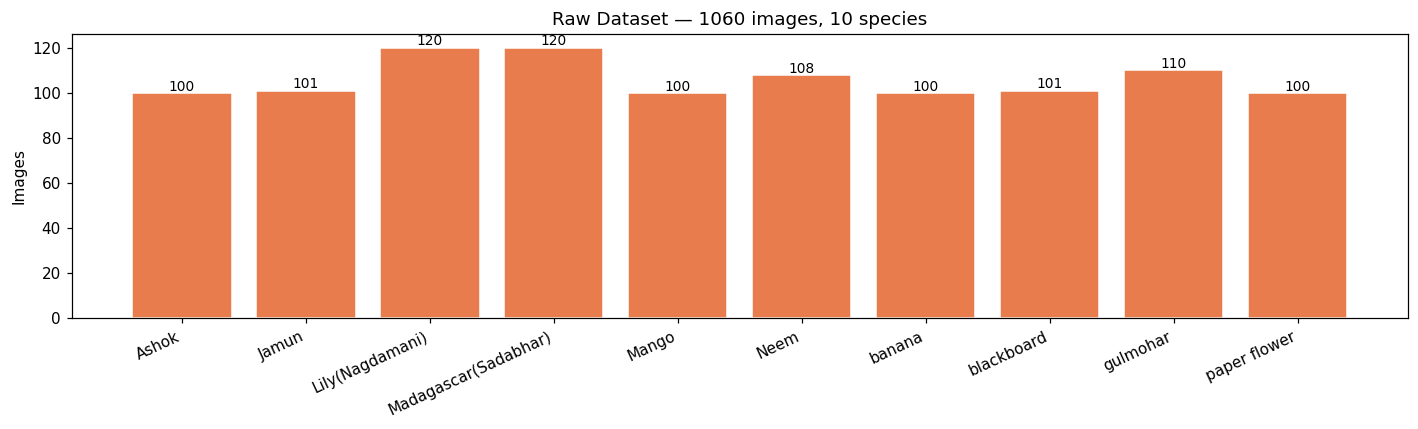

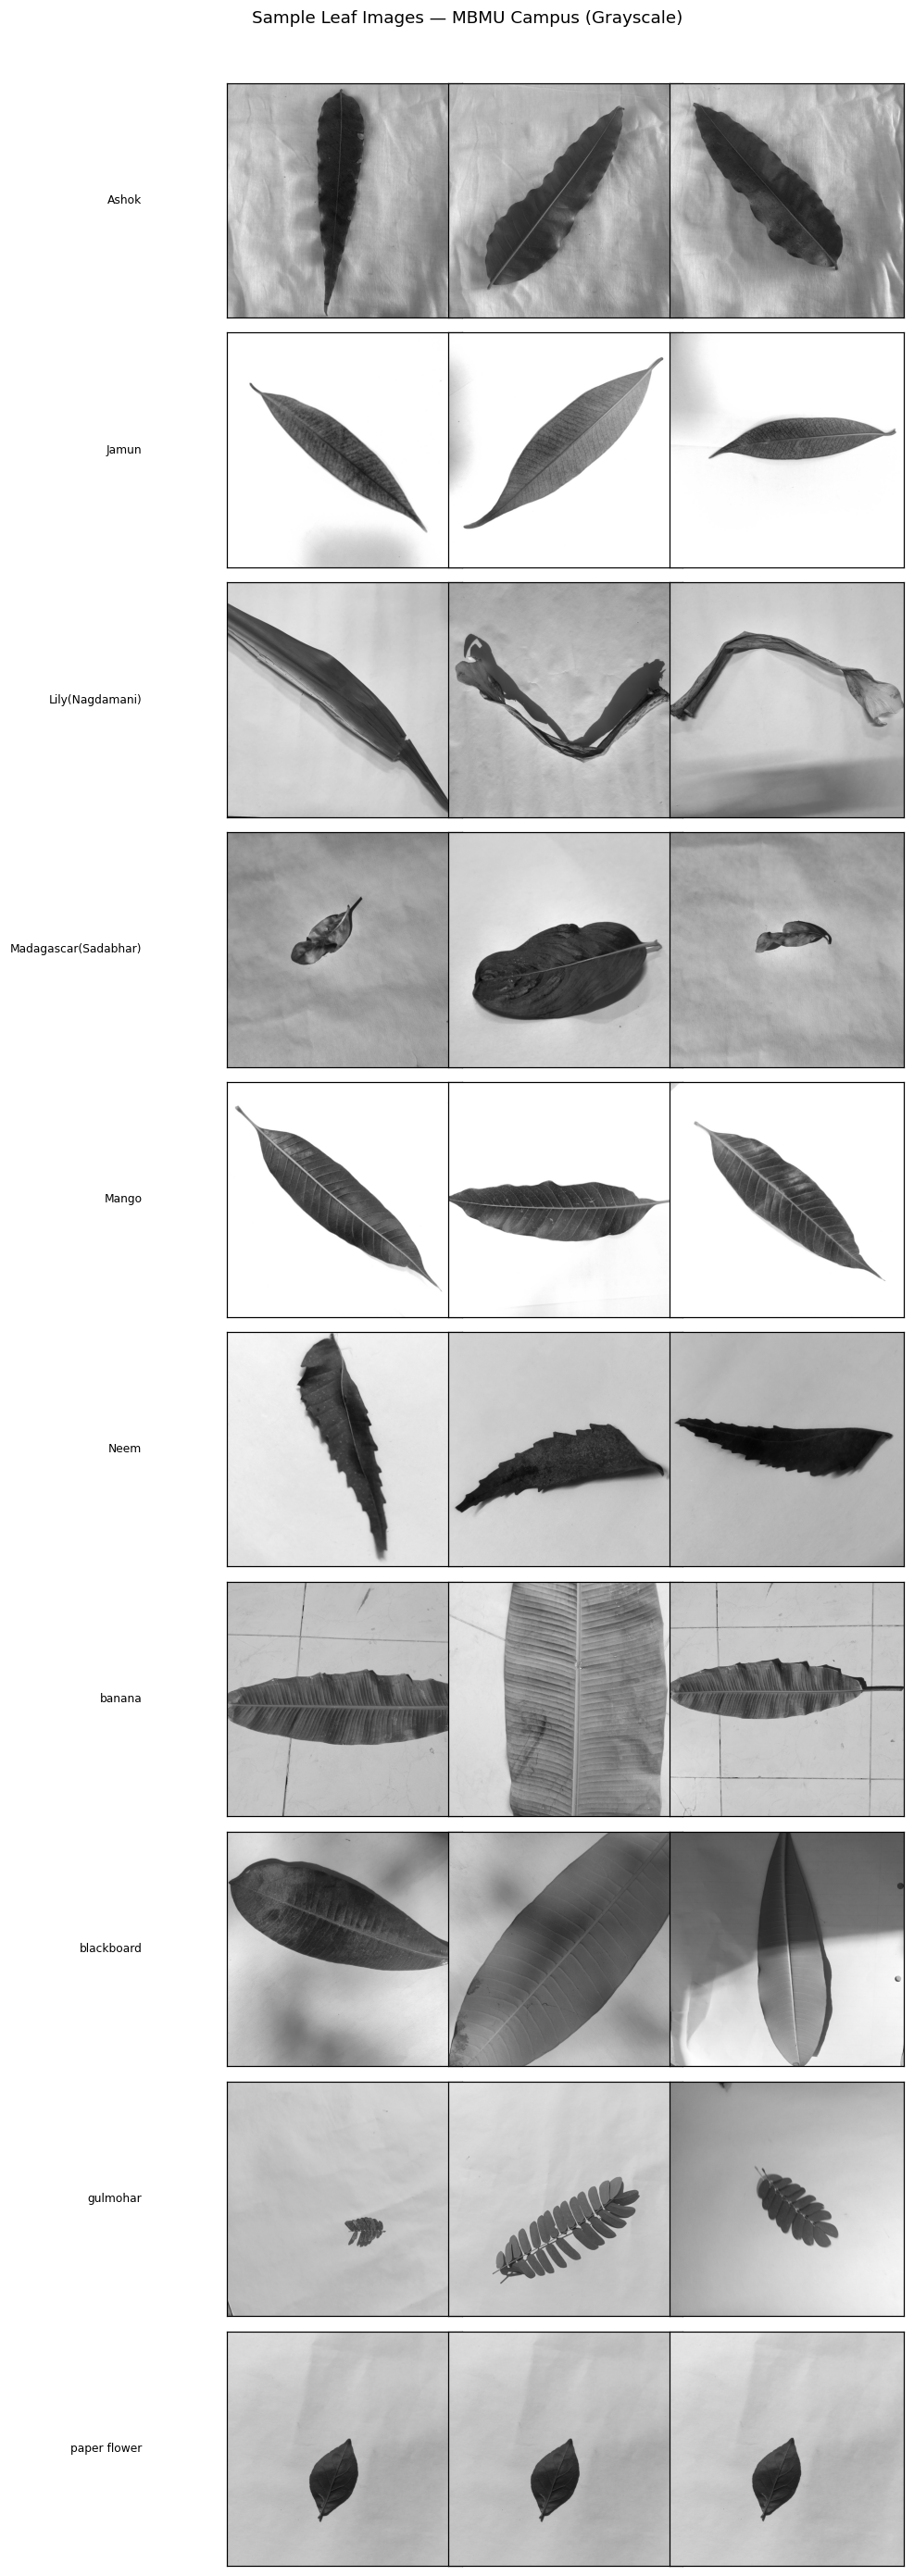

  Charts saved to /kaggle/working/outputs/


In [7]:
print('='*55)
print('  STEP 1 — Load Raw Dataset')
print('='*55)

raw_species   = {}
all_img_paths = []

for sp_dir in sorted(Path(RAW_FOLDER).iterdir()):
    if not sp_dir.is_dir(): continue
    imgs = list(sp_dir.glob('*.jpg')) + list(sp_dir.glob('*.JPG')) + \
           list(sp_dir.glob('*.png')) + list(sp_dir.glob('*.PNG')) + \
           list(sp_dir.glob('*.jpeg'))+ list(sp_dir.glob('*.JPEG'))
    if not imgs: continue
    raw_species[sp_dir.name] = imgs
    all_img_paths.extend(imgs)
    print(f'  {sp_dir.name:<35} {len(imgs):>4} images')

print(f'\n  Total species : {len(raw_species)}')
print(f'  Total images  : {len(all_img_paths)}')

# Distribution chart
plt.figure(figsize=(13, 4))
bars = plt.bar(raw_species.keys(),
               [len(v) for v in raw_species.values()],
               color='#E87C4C', edgecolor='white')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             str(int(b.get_height())), ha='center', fontsize=9)
plt.title(f'Raw Dataset — {len(all_img_paths)} images, {len(raw_species)} species')
plt.ylabel('Images'); plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'raw_distribution.png'), dpi=150)
plt.show()

# Sample images grid
n_sp = len(raw_species)
fig, axes = plt.subplots(n_sp, 3, figsize=(9, n_sp*2.5))
for row,(sp_name,img_list) in enumerate(raw_species.items()):
    samples = random.sample(img_list, min(3, len(img_list)))
    for col in range(3):
        ax = axes[row][col] if n_sp > 1 else axes[col]
        if col < len(samples):
            ax.imshow(Image.open(samples[col]).convert('L'), cmap='gray')
            if col == 0:
                ax.set_ylabel(sp_name, fontsize=8, rotation=0,
                              ha='right', va='center', labelpad=60)
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Sample Leaf Images — MBMU Campus (Grayscale)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()
print('  Charts saved to /kaggle/working/outputs/')

## Cell 6 — Augment Dataset to 4000 Images

In [8]:
print('='*55)
print('  STEP 2 — Augment Dataset')
print(f'  Target: {TARGET_TOTAL} total images')
print('='*55)

# Skip if already done
SKIP_AUG = False
if Path(AUGMENT_FOLDER).exists():
    existing = sum(len(list(sp.glob('*.jpg')))
                   for sp in Path(AUGMENT_FOLDER).iterdir() if sp.is_dir())
    if existing >= TARGET_TOTAL * 0.9:
        print(f'  Already exists: {existing:,} images — skipping augmentation')
        SKIP_AUG = True
    else:
        shutil.rmtree(AUGMENT_FOLDER)
        os.makedirs(AUGMENT_FOLDER, exist_ok=True)

if not SKIP_AUG:
    n_species       = len(raw_species)
    per_species_tgt = TARGET_TOTAL // n_species
    raw_per_species = len(all_img_paths) // n_species
    augments_needed = max(1, per_species_tgt // raw_per_species - 1)

    print(f'  Species        : {n_species}')
    print(f'  Per species    : {per_species_tgt} images')
    print(f'  Augments/image : {augments_needed}')
    print(f'  Expected total : ~{n_species * per_species_tgt:,} images\n')

    AUG_POOL = [
        T.RandomHorizontalFlip(p=1.0),
        T.RandomVerticalFlip(p=1.0),
        T.RandomRotation(degrees=30),
        T.RandomRotation(degrees=90),
        T.RandomRotation(degrees=180),
        T.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
        T.RandomAffine(15, translate=(0.1,0.1), shear=10),
        T.CenterCrop(int(IMAGE_SIZE*0.85)),
        T.RandomAutocontrast(p=1.0),
        T.RandomEqualize(p=1.0),
        T.RandomAdjustSharpness(2.5, p=1.0),
        T.RandomAdjustSharpness(0.0, p=1.0),
        T.GaussianBlur(5, (0.5, 2.0)),
        T.RandomPosterize(4, p=1.0),
        T.RandomSolarize(128, p=1.0),
    ]

    def augment_one(img_pil, n):
        base = T.Compose([T.Grayscale(1), T.Resize((IMAGE_SIZE, IMAGE_SIZE))])
        img  = base(img_pil)
        out  = []
        for _ in range(n):
            k     = np.random.randint(2, 5)
            chain = T.Compose([AUG_POOL[j]
                               for j in np.random.choice(len(AUG_POOL), k, replace=False)])
            try:    aug = T.Resize((IMAGE_SIZE, IMAGE_SIZE))(chain(img))
            except: aug = img
            out.append(aug)
        return out

    print(f'  {"Species":<35} {"Orig":>6}  {"Total":>8}')
    print(f'  {"-"*53}')
    total_orig = total_aug = 0

    for sp_dir in sorted(Path(RAW_FOLDER).iterdir()):
        if not sp_dir.is_dir(): continue
        sp_clean = (sp_dir.name.replace('(','').replace(')','')
                              .replace(' ','_').strip())
        out_dir  = Path(AUGMENT_FOLDER) / sp_clean
        out_dir.mkdir(parents=True, exist_ok=True)

        imgs   = list(sp_dir.glob('*.jpg')) + list(sp_dir.glob('*.JPG')) + \
                 list(sp_dir.glob('*.png')) + list(sp_dir.glob('*.PNG'))
        sp_tot = 0

        for img_path in imgs:
            shutil.copy2(img_path, out_dir / img_path.name)
            sp_tot += 1
            if sp_tot >= per_species_tgt: break
            try:
                remaining = per_species_tgt - sp_tot
                n_aug     = min(augments_needed, remaining)
                augs      = augment_one(Image.open(img_path), n_aug)
                for j, aug in enumerate(augs):
                    if sp_tot >= per_species_tgt: break
                    aug.save(str(out_dir / f'{img_path.stem}_aug{j+1:03d}.jpg'),
                             'JPEG', quality=92)
                    sp_tot += 1
            except: pass

        total_orig += len(imgs)
        total_aug  += sp_tot
        print(f'  {sp_clean:<35} {len(imgs):>6}  {sp_tot:>8}')

    print(f'  {"-"*53}')
    print(f'  {"TOTAL":<35} {total_orig:>6}  {total_aug:>8}')
    print(f'\n  ✅ Augmentation complete ({total_aug:,} images)')

  STEP 2 — Augment Dataset
  Target: 4000 total images
  Species        : 10
  Per species    : 400 images
  Augments/image : 2
  Expected total : ~4,000 images

  Species                               Orig     Total
  -----------------------------------------------------
  Ashok                                  100       300
  Jamun                                  101       303
  LilyNagdamani                          120       360
  MadagascarSadabhar                     120       360
  Mango                                  100       300
  Neem                                   108       324
  banana                                 100       300
  blackboard                             101       303
  gulmohar                               110       330
  paper_flower                           100       300
  -----------------------------------------------------
  TOTAL                                 1060      3180

  ✅ Augmentation complete (3,180 images)


## Cell 7 — Model Definitions (Encoder, SimCLR, Classifier)

In [11]:
# ── Encoder: ResNet-18 modified for 1-channel grayscale input ──
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        base          = models.resnet18(weights=None)
        base.conv1    = nn.Conv2d(1, 64, 7, 2, 3, bias=False)  # grayscale
        self.feat_dim = base.fc.in_features  # 512
        base.fc       = nn.Identity()
        self.backbone = base
    def forward(self, x): return self.backbone(x)


# ── SimCLR: Encoder + MLP projection head ──
class SimCLR(nn.Module):
    def __init__(self, encoder, proj_dim=128):
        super().__init__()
        self.encoder   = encoder
        self.projector = nn.Sequential(
            nn.Linear(encoder.feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, proj_dim)
        )
    def forward(self, x):
        return F.normalize(self.projector(self.encoder(x)), dim=1)


# ── NT-Xent Contrastive Loss — NOT pixel reconstruction ──
class NTXentLoss(nn.Module):
    """
    NT-Xent (Normalized Temperature-scaled Cross Entropy) loss.
    Operates on embeddings in representation space — no pixel reconstruction.
    Two augmented views of the same image are pulled together;
    all other pairs in the batch are pushed apart.
    """
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temp = temperature
        self.ce   = nn.CrossEntropyLoss()
    def forward(self, z1, z2):
        B   = z1.size(0)
        z   = torch.cat([z1, z2])                          # (2B, D)
        sim = torch.mm(z, z.T) / self.temp                 # cosine similarity
        sim.masked_fill_(
            torch.eye(2*B, device=z.device).bool(), float('-inf')
        )
        lbl = torch.cat([
            torch.arange(B, 2*B, device=z.device),
            torch.arange(0,   B, device=z.device)
        ])
        return self.ce(sim, lbl)


# ── LeafClassifier: frozen SSL encoder + trainable linear head ──
class LeafClassifier(nn.Module):
    def __init__(self, encoder, num_classes, freeze=True):
        super().__init__()
        self.encoder = encoder
        if freeze:
            for p in encoder.parameters():
                p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(encoder.feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.head(self.encoder(x))


# Sanity check
_enc = Encoder()
_mdl = SimCLR(_enc, PROJECTION_DIM)
_x   = torch.zeros(2, 1, SSL_IMAGE_SIZE, SSL_IMAGE_SIZE)
_z   = _mdl(_x)
print('  ✅ Models defined')
print(f'  Encoder output    : {_enc.feat_dim}-dim')
print(f'  Projection output : {_z.shape[1]}-dim')
print(f'  Parameters        : {sum(p.numel() for p in _mdl.parameters())/1e6:.2f}M')
print(f'  Loss type         : NT-Xent contrastive (NO pixel reconstruction)')
del _enc, _mdl, _x, _z

  ✅ Models defined
  Encoder output    : 512-dim
  Projection output : 128-dim
  Parameters        : 11.50M
  Loss type         : NT-Xent contrastive (NO pixel reconstruction)


## Cell 8 — SSL Pre-Training (SimCLR with NT-Xent Loss)

  SSL DataLoader ready
  Image size    : 96×96
  Dataset       : 3,180 images
  Batches/epoch : 15  (of 12 total)
  Batch size    : 256
  Epochs        : 50
  🗑️  Old SSL checkpoint deleted


  🚀 SSL Pre-Training on cuda
  Epoch    Loss         LR             Time/epoch   ETA
  ------------------------------------------------------------
  1        5.3190       0.000300       62s           ~50.4 min
  2        4.9466       0.000299       60s           ~48.3 min
  3        4.8288       0.000297       61s           ~48.1 min
  4        4.7613       0.000295       60s           ~45.8 min
  5        4.7316       0.000293       60s           ~44.9 min
  6        4.6887       0.000289       61s           ~44.5 min
  7        4.6789       0.000286       59s           ~42.5 min
  8        4.6589       0.000281       59s           ~41.5 min
  9        4.6320       0.000277       60s           ~40.8 min
  10       4.6261       0.000271       60s           ~40.2 min
  11       4.6324       0.0002

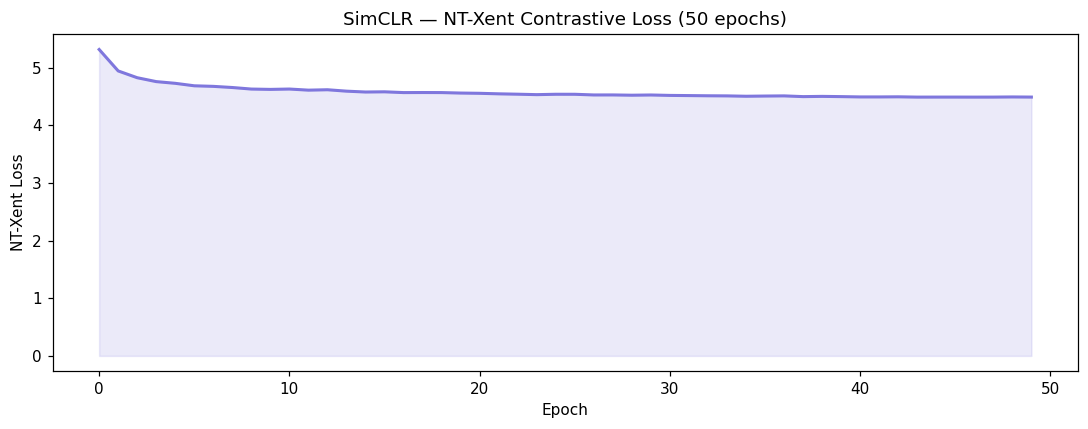

  Loss curve saved.


In [12]:
# ── Two-view dataset for contrastive learning ──
class TwoViewDataset(Dataset):
    """Returns two independently augmented views of the same image."""
    def __init__(self, root, sz):
        self.ds  = ImageFolder(root)
        self.aug = T.Compose([
            T.Grayscale(1),
            T.RandomResizedCrop(sz, scale=(0.2, 1.0)),
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.3),
            T.RandomRotation(30),
            T.ToTensor(),
            T.Normalize([0.5], [0.5])
        ])
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        img, _ = self.ds[idx]
        return self.aug(img), self.aug(img)   # two different augmented views


ssl_ds  = TwoViewDataset(AUGMENT_FOLDER, SSL_IMAGE_SIZE)
ssl_ldr = DataLoader(
    ssl_ds,
    batch_size         = SSL_BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    drop_last          = True,
    persistent_workers = True,
    prefetch_factor    = 2
)

print(f'  SSL DataLoader ready')
print(f'  Image size    : {SSL_IMAGE_SIZE}×{SSL_IMAGE_SIZE}')
print(f'  Dataset       : {len(ssl_ds):,} images')
print(f'  Batches/epoch : {MAX_BATCHES}  (of {len(ssl_ldr)} total)')
print(f'  Batch size    : {SSL_BATCH_SIZE}')
print(f'  Epochs        : {SSL_EPOCHS}')

# ── Build model ──
encoder   = Encoder()
ssl_model = SimCLR(encoder, PROJECTION_DIM).to(DEVICE)
criterion = NTXentLoss(TEMPERATURE)
optimizer = optim.Adam(ssl_model.parameters(), lr=SSL_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SSL_EPOCHS)

ssl_losses = []
best_loss  = float('inf')

# Remove stale checkpoint
if Path(SSL_CKPT).exists():
    os.remove(SSL_CKPT)
    print('  🗑️  Old SSL checkpoint deleted\n')

print(f'\n  🚀 SSL Pre-Training on {DEVICE}')
print(f'  {"Epoch":<8} {"Loss":<12} {"LR":<14} {"Time/epoch":<12} {"ETA"}')
print(f'  {"-"*60}')

for epoch in range(1, SSL_EPOCHS + 1):
    ssl_model.train()
    t0      = time.time()
    ep_loss = 0.0
    batches = 0

    for v1, v2 in ssl_ldr:
        if batches >= MAX_BATCHES: break
        v1   = v1.to(DEVICE, non_blocking=True)
        v2   = v2.to(DEVICE, non_blocking=True)
        loss = criterion(ssl_model(v1), ssl_model(v2))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
        batches += 1

    avg     = ep_loss / batches
    elapsed = time.time() - t0
    ssl_losses.append(avg)
    scheduler.step()

    remaining = (SSL_EPOCHS - epoch) * elapsed
    print(f'  {epoch:<8} {avg:<12.4f} '
          f'{scheduler.get_last_lr()[0]:<14.6f} {elapsed:.0f}s           '
          f'~{remaining/60:.1f} min')

    if avg < best_loss:
        best_loss = avg
        torch.save({
            'model_state'     : ssl_model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'scheduler_state' : scheduler.state_dict(),
            'epoch'           : epoch,
            'loss'            : avg
        }, SSL_CKPT)

print(f'\n  ✅ Pre-training complete | Best loss: {best_loss:.4f}')

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(ssl_losses, linewidth=2, color='#7F77DD')
plt.fill_between(range(len(ssl_losses)), ssl_losses, alpha=0.15, color='#7F77DD')
plt.title(f'SimCLR — NT-Xent Contrastive Loss ({SSL_EPOCHS} epochs)')
plt.xlabel('Epoch'); plt.ylabel('NT-Xent Loss')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ssl_loss.png'), dpi=150)
plt.show()
print('  Loss curve saved.')

## Cell 9 — Fine-Tuning (Frozen Encoder + Linear Head)

  STEP 3 — Fine-Tune on Labelled Data
  Train: 2,226  |  Val: 477  |  Test: 477
  Classes (10): ['Ashok', 'Jamun', 'LilyNagdamani', 'MadagascarSadabhar', 'Mango', 'Neem', 'banana', 'blackboard', 'gulmohar', 'paper_flower']

  ✅ SSL encoder loaded | Trainable params: 134,410 (encoder frozen)

  Epoch    Tr Loss    Tr Acc     Val Loss   Val Acc
  ----------------------------------------------------
  1        1.5354     0.528      1.2632     0.675
  5        1.2634     0.639      1.1582     0.715
  10       1.1953     0.684      1.1098     0.713
  15       1.1314     0.721      1.0625     0.759
  20       1.0933     0.730      1.0464     0.761
  25       1.0600     0.755      1.0296     0.769
  30       1.0615     0.756      1.0206     0.778

  ✅ Fine-tuning done | Best val accuracy: 0.7904 (79.04%)


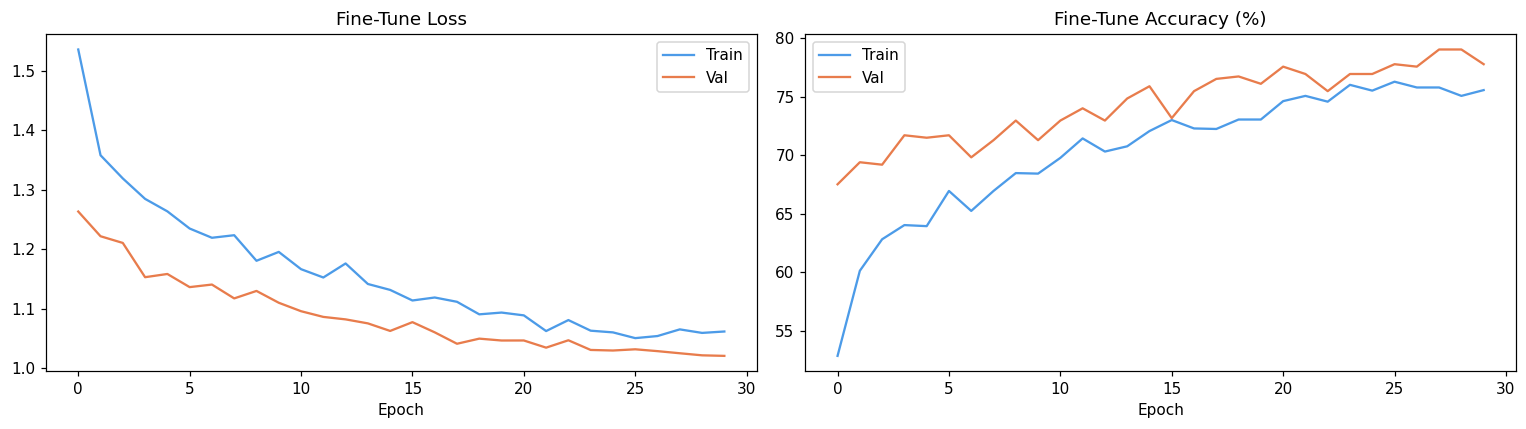

In [13]:
print('='*55)
print('  STEP 3 — Fine-Tune on Labelled Data')
print('='*55)

# Transforms
train_tf = T.Compose([
    T.Grayscale(1),
    T.Resize((IMAGE_SIZE+20, IMAGE_SIZE+20)),
    T.RandomCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize([0.5],[0.5])
])
eval_tf = T.Compose([
    T.Grayscale(1),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5],[0.5])
])

# Dataset split: 70% train | 15% val | 15% test
full_tr = ImageFolder(AUGMENT_FOLDER, transform=train_tf)
full_ev = ImageFolder(AUGMENT_FOLDER, transform=eval_tf)
n       = len(full_tr)
n_tr    = int(n*0.70)
n_vl    = int(n*0.15)
n_ts    = n - n_tr - n_vl
g       = torch.Generator().manual_seed(SEED)
tr_ds, vl_ds, _  = random_split(full_tr, [n_tr, n_vl, n_ts], generator=g)
g2      = torch.Generator().manual_seed(SEED)
_, _,    ts_ds   = random_split(full_ev, [n_tr, n_vl, n_ts], generator=g2)

kw     = dict(num_workers=NUM_WORKERS, pin_memory=True)
tr_ldr = DataLoader(tr_ds, BATCH_SIZE, shuffle=True,  **kw)
vl_ldr = DataLoader(vl_ds, BATCH_SIZE, shuffle=False, **kw)
ts_ldr = DataLoader(ts_ds, BATCH_SIZE, shuffle=False, **kw)

CLASS_NAMES = full_tr.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'  Train: {len(tr_ds):,}  |  Val: {n_vl:,}  |  Test: {n_ts:,}')
print(f'  Classes ({NUM_CLASSES}): {CLASS_NAMES}\n')

# Load SSL pretrained encoder
enc     = Encoder()
raw_wts = torch.load(SSL_CKPT, map_location=DEVICE)['model_state']
enc_wts = {k.replace('encoder.',''): v
           for k,v in raw_wts.items() if k.startswith('encoder.')}
enc.load_state_dict(enc_wts)
enc     = enc.to(DEVICE)

ft_model  = LeafClassifier(enc, NUM_CLASSES, freeze=True).to(DEVICE)
trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f'  ✅ SSL encoder loaded | Trainable params: {trainable:,} (encoder frozen)')

ce_loss  = nn.CrossEntropyLoss(label_smoothing=0.1)
ft_optim = optim.Adam(ft_model.head.parameters(), lr=FT_LR, weight_decay=1e-4)
ft_sched = optim.lr_scheduler.CosineAnnealingLR(ft_optim, T_max=FT_EPOCHS)

tr_losses, vl_losses, tr_accs, vl_accs = [], [], [], []
best_val = 0.0

print(f'\n  {"Epoch":<8} {"Tr Loss":<10} {"Tr Acc":<10} {"Val Loss":<10} {"Val Acc"}')
print(f'  {"-"*52}')

for epoch in range(1, FT_EPOCHS+1):
    # Train
    ft_model.train(); tl=tc=tt=0
    for imgs,lbls in tr_ldr:
        imgs,lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out  = ft_model(imgs); loss = ce_loss(out, lbls)
        ft_optim.zero_grad(); loss.backward(); ft_optim.step()
        tl += loss.item()
        tc += (out.argmax(1)==lbls).sum().item()
        tt += lbls.size(0)

    # Validate
    ft_model.eval(); vl=vc=vt=0
    with torch.no_grad():
        for imgs,lbls in vl_ldr:
            imgs,lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = ft_model(imgs)
            vl += ce_loss(out,lbls).item()
            vc += (out.argmax(1)==lbls).sum().item()
            vt += lbls.size(0)

    t_loss=tl/len(tr_ldr); v_loss=vl/len(vl_ldr)
    t_acc=tc/tt;            v_acc=vc/vt
    tr_losses.append(t_loss); vl_losses.append(v_loss)
    tr_accs.append(t_acc);   vl_accs.append(v_acc)
    ft_sched.step()

    if epoch%5==0 or epoch==1:
        print(f'  {epoch:<8} {t_loss:<10.4f} {t_acc:<10.3f} {v_loss:<10.4f} {v_acc:.3f}')

    if v_acc > best_val:
        best_val = v_acc
        torch.save({'model_state': ft_model.state_dict(),
                    'class_names': CLASS_NAMES}, FT_CKPT)

print(f'\n  ✅ Fine-tuning done | Best val accuracy: {best_val:.4f} ({best_val*100:.2f}%)')

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(tr_losses, label='Train', color='#4C9BE8')
ax1.plot(vl_losses, label='Val',   color='#E87C4C')
ax1.set_title('Fine-Tune Loss'); ax1.set_xlabel('Epoch')
ax1.legend()
ax2.plot([a*100 for a in tr_accs], label='Train', color='#4C9BE8')
ax2.plot([a*100 for a in vl_accs], label='Val',   color='#E87C4C')
ax2.set_title('Fine-Tune Accuracy (%)'); ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'finetune_curves.png'), dpi=150)
plt.show()

## Cell 10 — Test Set Evaluation & Confusion Matrix

  STEP 4 — Final Test Evaluation

  Test Accuracy : 0.7568 (75.68%)
  Correct       : 361 / 477

  Classification Report:
                    precision    recall  f1-score   support

             Ashok      0.912     0.897     0.904        58
             Jamun      0.750     0.698     0.723        43
     LilyNagdamani      0.630     0.767     0.692        60
MadagascarSadabhar      0.750     0.621     0.679        58
             Mango      0.720     0.783     0.750        46
              Neem      0.763     0.690     0.725        42
            banana      0.681     0.821     0.744        39
        blackboard      0.718     0.778     0.747        36
          gulmohar      0.919     0.680     0.782        50
      paper_flower      0.792     0.844     0.817        45

          accuracy                          0.757       477
         macro avg      0.763     0.758     0.756       477
      weighted avg      0.766     0.757     0.757       477



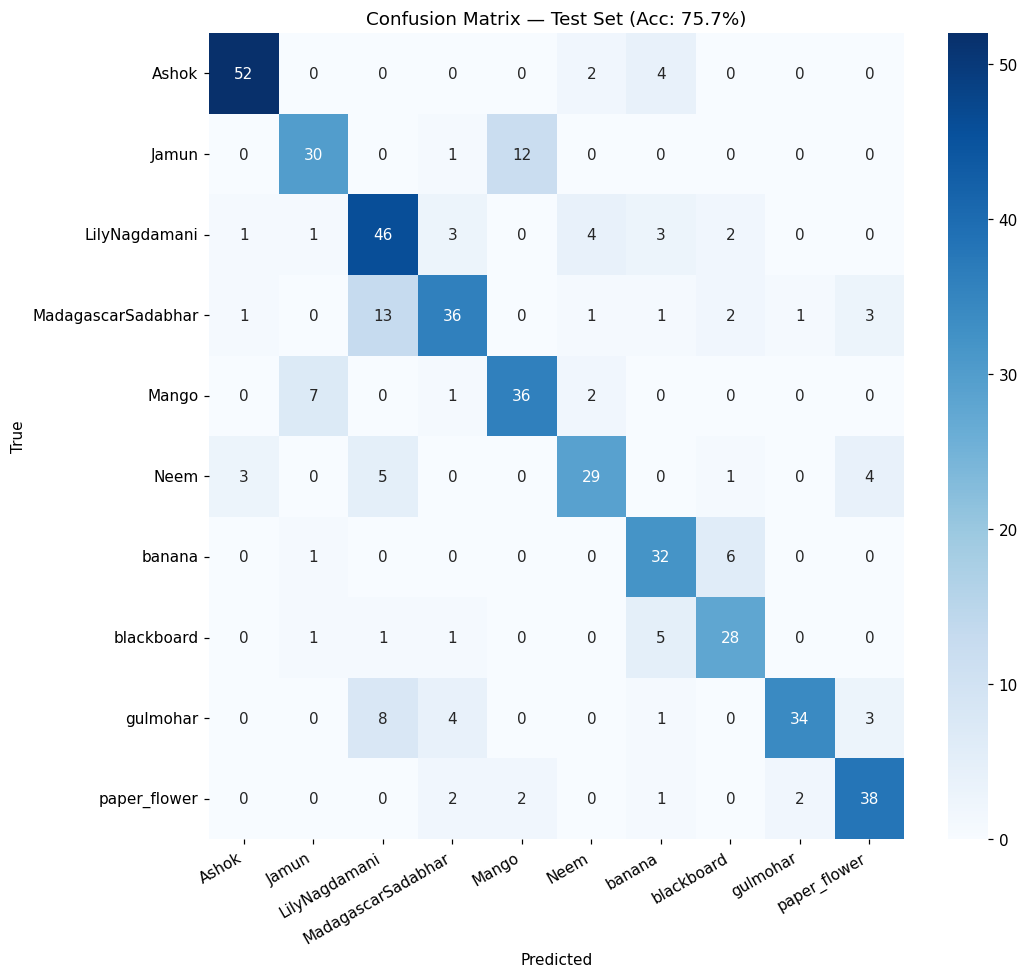

In [15]:
print('='*55)
print('  STEP 4 — Final Test Evaluation')
print('='*55)

# Load best checkpoint
ckpt     = torch.load(FT_CKPT, map_location=DEVICE)
enc_best = Encoder()
best_model = LeafClassifier(enc_best, NUM_CLASSES, freeze=False).to(DEVICE)
best_model.load_state_dict(ckpt['model_state'])
best_model.eval()

all_preds, all_labels = [], []
correct = total = 0

with torch.no_grad():
    for imgs, lbls in ts_ldr:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        preds      = best_model(imgs).argmax(1)
        correct   += (preds == lbls).sum().item()
        total     += lbls.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(lbls.cpu().tolist())

test_acc = correct / total
print(f'\n  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Correct       : {correct} / {total}\n')
print('  Classification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=3))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES-1)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix — Test Set (Acc: {test_acc*100:.1f}%)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'confusion_matrix.png'), dpi=150)
plt.show()

Testing of Data

## Cell 12 — Bonus: Cross-Season Robustness Analysis

**Comment on cross-season robustness:**

Leaf appearance changes significantly across seasons — texture, colour/intensity, shape, and surface detail all vary. The table below simulates seasonal effects using photometric transforms and measures model accuracy under each condition.

In [23]:
import os, random, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Paths (must match your main notebook) ──────────────────────
AUGMENT_FOLDER = '/kaggle/working/augmented_dataset'
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
OUTPUT_DIR     = '/kaggle/working/outputs'
FT_CKPT        = os.path.join(CHECKPOINT_DIR, 'finetuned.pth')

IMAGE_SIZE   = 224
BATCH_SIZE   = 64
NUM_WORKERS  = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'  Device         : {DEVICE}')
print(f'  Augment folder : {Path(AUGMENT_FOLDER).exists()}')
print(f'  FT checkpoint  : {Path(FT_CKPT).exists()}')

  Device         : cuda
  Augment folder : True
  FT checkpoint  : True


Step 2 — Re-define Model Classes

In [24]:
# Must re-define here if running as a standalone notebook

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        base          = models.resnet18(weights=None)
        base.conv1    = nn.Conv2d(1, 64, 7, 2, 3, bias=False)  # 1-channel grayscale
        self.feat_dim = base.fc.in_features  # 512
        base.fc       = nn.Identity()
        self.backbone = base
    def forward(self, x): return self.backbone(x)


class LeafClassifier(nn.Module):
    def __init__(self, encoder, num_classes, freeze=False):
        super().__init__()
        self.encoder = encoder
        if freeze:
            for p in encoder.parameters():
                p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(encoder.feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.head(self.encoder(x))


print('  Model classes defined')

  Model classes defined


Step 3 — Load Trained Model & Class Name

In [25]:
# Load checkpoint
assert Path(FT_CKPT).exists(), f'Checkpoint not found: {FT_CKPT}\nRun the main notebook first!'

ckpt        = torch.load(FT_CKPT, map_location=DEVICE)
CLASS_NAMES = ckpt['class_names']
NUM_CLASSES = len(CLASS_NAMES)

enc   = Encoder()
model = LeafClassifier(enc, NUM_CLASSES, freeze=False).to(DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'  Model loaded successfully')
print(f'  Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Build consistent test split indices (same seed as main notebook)
base_ds = ImageFolder(AUGMENT_FOLDER,
                      transform=T.Compose([
                          T.Grayscale(1),
                          T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                          T.ToTensor(),
                          T.Normalize([0.5],[0.5])
                      ]))

n    = len(base_ds)
n_tr = int(n * 0.70)
n_vl = int(n * 0.15)
n_ts = n - n_tr - n_vl

print(f'  Dataset total  : {n:,}')
print(f'  Test split     : {n_ts:,} images')

  Model loaded successfully
  Classes (10): ['Ashok', 'Jamun', 'LilyNagdamani', 'MadagascarSadabhar', 'Mango', 'Neem', 'banana', 'blackboard', 'gulmohar', 'paper_flower']
  Dataset total  : 3,180
  Test split     : 477 images


Step 4 — Define Season Transforms
Each transform simulates the photometric changes a leaf undergoes in that season:

Spring — Fresh leaves have sharper vein edges and higher local contrast. Simulated with autocontrast + sharpening.
Summer — Normal appearance. This is our baseline (no transform).
Autumn — Leaves begin to yellow and degrade. Texture softens, contrast drops. Simulated with sharpness reduction.
Winter — Dry/bare leaves or leaves under poor lighting. Blurry, dim, high noise. Simulated with Gaussian blur and dimmer normalization.

In [26]:
# Base resize+grayscale applied to all seasons
BASE = [
    T.Grayscale(1),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
]

SEASON_TRANSFORMS = {

    'Summer (baseline)': T.Compose(BASE + [
        # No photometric change — this is what the model was trained on
        T.ToTensor(),
        T.Normalize([0.5], [0.5])
    ]),

    'Spring (sharp + high contrast)': T.Compose(BASE + [
        # Fresh leaves: sharper edges, higher contrast
        T.RandomAutocontrast(p=1.0),
        T.RandomAdjustSharpness(sharpness_factor=2.5, p=1.0),
        T.ToTensor(),
        T.Normalize([0.5], [0.5])
    ]),

    'Autumn (soft + low contrast)': T.Compose(BASE + [
        # Yellowing/degrading leaves: reduced sharpness, lower contrast
        T.RandomAdjustSharpness(sharpness_factor=0.2, p=1.0),
        T.ToTensor(),
        # Slightly compressed dynamic range to simulate faded appearance
        T.Normalize([0.45], [0.45])
    ]),

    'Winter (blurry + dim)': T.Compose(BASE + [
        # Dry/dead leaves or poor lighting: heavy blur, noise, dim
        T.GaussianBlur(kernel_size=7, sigma=(2.0, 4.0)),
        T.RandomAdjustSharpness(sharpness_factor=0.0, p=1.0),
        T.ToTensor(),
        # Dimmer normalization: mean higher → image appears darker overall
        T.Normalize([0.65], [0.35])
    ]),
}

SEASON_COLORS = {
    'Summer (baseline)'             : '#4CAF50',
    'Spring (sharp + high contrast)': '#4C9BE8',
    'Autumn (soft + low contrast)'  : '#E8A74C',
    'Winter (blurry + dim)'         : '#9E9E9E',
}

print('  Season transforms defined:')
for name in SEASON_TRANSFORMS:
    print(f'    {name}')

  Season transforms defined:
    Summer (baseline)
    Spring (sharp + high contrast)
    Autumn (soft + low contrast)
    Winter (blurry + dim)


Step 5 — Visualize Season Effects on Sample Images

Visualizing season transform effects on sample images...


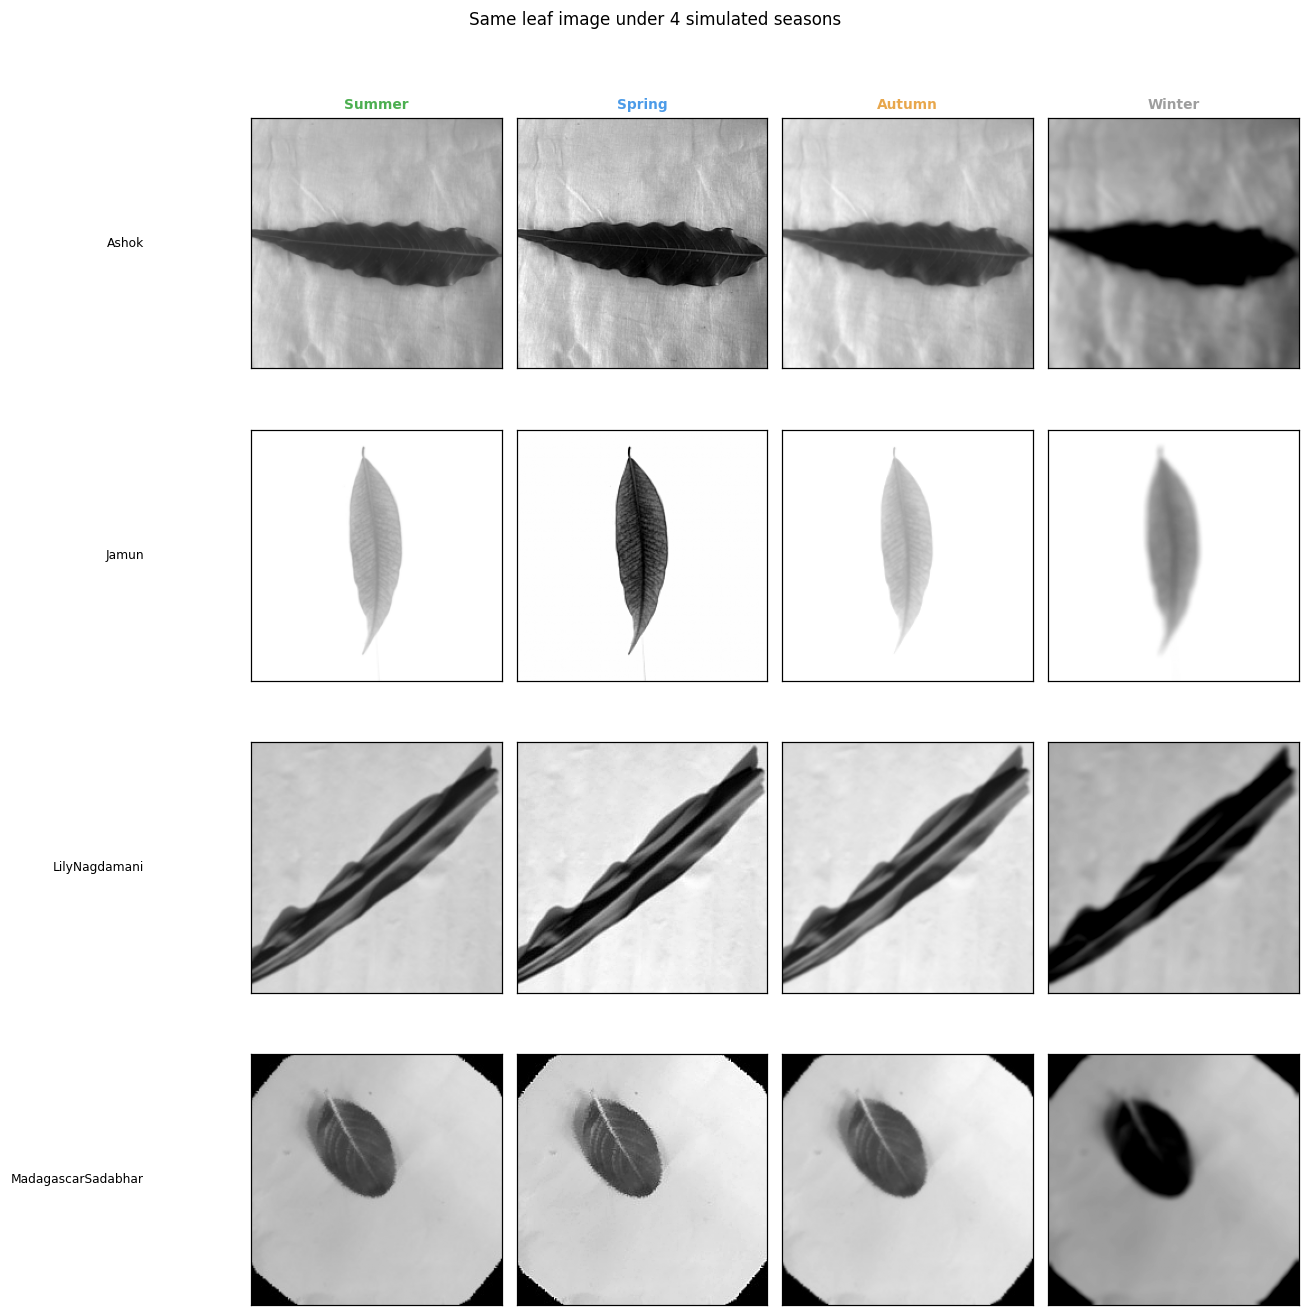

  Saved: season_visual_comparison.png


In [27]:
print('Visualizing season transform effects on sample images...')

# Pick one image per class for demonstration
sample_paths = []
for cls in CLASS_NAMES[:min(4, NUM_CLASSES)]:
    cls_dir = Path(AUGMENT_FOLDER) / cls
    imgs    = list(cls_dir.glob('*.jpg'))[:1]
    if imgs:
        sample_paths.append((cls, imgs[0]))

from PIL import Image

n_seasons = len(SEASON_TRANSFORMS)
n_samples = len(sample_paths)
fig, axes = plt.subplots(n_samples, n_seasons, figsize=(n_seasons * 3, n_samples * 3))

if n_samples == 1:
    axes = [axes]

for row, (cls_name, img_path) in enumerate(sample_paths):
    raw_img = Image.open(img_path).convert('L')
    for col, (season_name, season_tf) in enumerate(SEASON_TRANSFORMS.items()):
        ax = axes[row][col]

        # Apply transform and convert back to numpy for display
        tensor = season_tf(raw_img)  # (1, H, W)
        # Denormalize for display
        img_np = tensor.squeeze().numpy()
        img_np = (img_np * 0.5 + 0.5).clip(0, 1)

        ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])

        if row == 0:
            short_name = season_name.split('(')[0].strip()
            ax.set_title(short_name, fontsize=9,
                         color=SEASON_COLORS[season_name], fontweight='bold')
        if col == 0:
            short_cls = cls_name[:18] + '...' if len(cls_name) > 18 else cls_name
            ax.set_ylabel(short_cls, fontsize=8, rotation=0,
                          ha='right', va='center', labelpad=70)

plt.suptitle('Same leaf image under 4 simulated seasons', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'season_visual_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: season_visual_comparison.png')

Step 6 — Evaluate Model Accuracy Per Season

In [28]:
print('='*65)
print('  Cross-Season Accuracy Evaluation')
print('='*65)

season_results   = {}   # season_name -> accuracy
season_reports   = {}   # season_name -> (preds, labels)
season_per_class = {}   # season_name -> {class: accuracy}

for season_name, season_tf in SEASON_TRANSFORMS.items():

    # Rebuild dataset with this season's transform
    season_ds = ImageFolder(AUGMENT_FOLDER, transform=season_tf)

    # Use EXACT same test split as main notebook (same seed)
    g         = torch.Generator().manual_seed(SEED)
    _, _, s_ts = random_split(season_ds, [n_tr, n_vl, n_ts], generator=g)

    s_ldr = DataLoader(s_ts, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

    # Run inference
    all_preds, all_labels = [], []
    correct = total = 0

    model.eval()
    with torch.no_grad():
        for imgs, lbls in s_ldr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            preds      = model(imgs).argmax(1)
            correct   += (preds == lbls).sum().item()
            total     += lbls.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(lbls.cpu().tolist())

    acc = correct / total
    season_results[season_name]  = acc
    season_reports[season_name]  = (all_preds, all_labels)

    # Per-class accuracy
    per_class = {}
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_mask   = [l == cls_idx for l in all_labels]
        cls_preds  = [p for p, m in zip(all_preds, cls_mask) if m]
        cls_labels = [l for l, m in zip(all_labels, cls_mask) if m]
        if cls_labels:
            per_class[cls_name] = sum(p==l for p,l in zip(cls_preds,cls_labels)) / len(cls_labels)
    season_per_class[season_name] = per_class

    # Progress bar
    bar  = '█' * int(acc * 30) + '░' * (30 - int(acc * 30))
    baseline_acc = list(season_results.values())[0]
    drop = acc - baseline_acc
    note = 'reference' if 'Summer' in season_name else f'drop: {drop:+.2%}'
    print(f'  {season_name:<38} {acc*100:>6.2f}%  [{bar}]  ({note})')

print()
print(f'  Best  : {max(season_results, key=season_results.get)}')
print(f'  Worst : {min(season_results, key=season_results.get)}')
baseline = season_results['Summer (baseline)']
worst    = min(season_results.values())
print(f'  Max accuracy drop : {worst - baseline:+.2%}')

  Cross-Season Accuracy Evaluation
  Summer (baseline)                       75.68%  [██████████████████████░░░░░░░░]  (reference)
  Spring (sharp + high contrast)          48.64%  [██████████████░░░░░░░░░░░░░░░░]  (drop: -27.04%)
  Autumn (soft + low contrast)            62.68%  [██████████████████░░░░░░░░░░░░]  (drop: -13.00%)
  Winter (blurry + dim)                   17.19%  [█████░░░░░░░░░░░░░░░░░░░░░░░░░]  (drop: -58.49%)

  Best  : Summer (baseline)
  Worst : Winter (blurry + dim)
  Max accuracy drop : -58.49%


Step 7 — Overall Accuracy Bar Chart

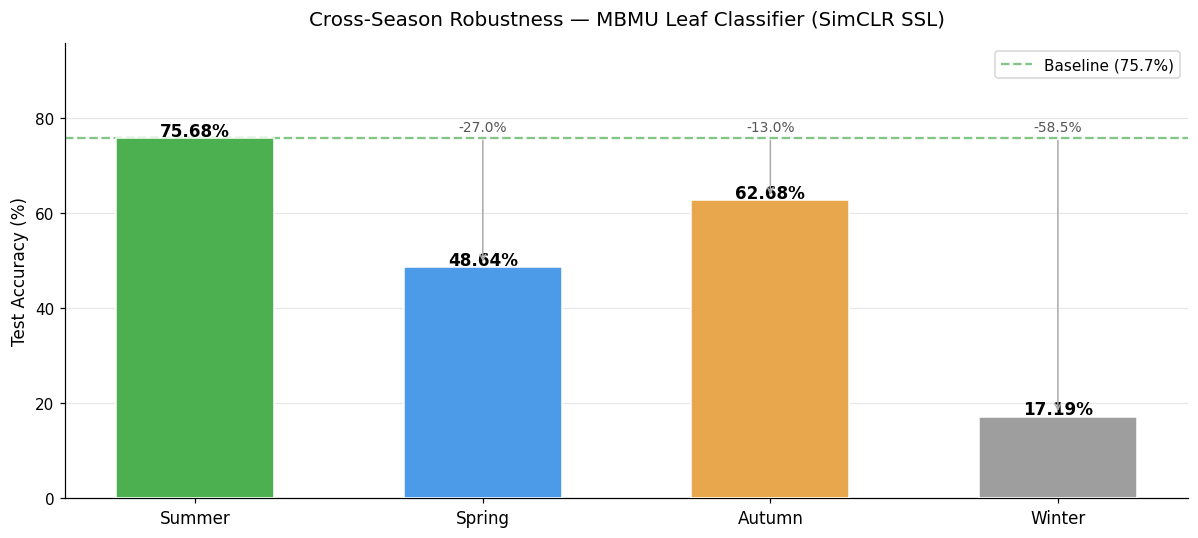

  Saved: cross_season_accuracy.png


In [29]:
fig, ax = plt.subplots(figsize=(11, 5))

names  = list(season_results.keys())
accs   = [v * 100 for v in season_results.values()]
colors = [SEASON_COLORS[n] for n in names]

bars = ax.bar(range(len(names)), accs, color=colors,
              edgecolor='white', width=0.55, zorder=3)

# Value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accs)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Drop annotations
baseline_acc = season_results['Summer (baseline)'] * 100
ax.axhline(y=baseline_acc, color='#4CAF50', linestyle='--',
           linewidth=1.5, alpha=0.7, label=f'Baseline ({baseline_acc:.1f}%)', zorder=2)

for i, (name, acc) in enumerate(season_results.items()):
    if 'Summer' not in name:
        drop = acc * 100 - baseline_acc
        ax.annotate(f'{drop:+.1f}%',
                    xy=(i, acc * 100 + 0.5),
                    xytext=(i, baseline_acc + 1.5),
                    fontsize=9, ha='center', color='#555',
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1))

ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names], fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_ylim(0, min(115, max(accs) + 20))
ax.set_title('Cross-Season Robustness — MBMU Leaf Classifier (SimCLR SSL)',
             fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cross_season_accuracy.png'), dpi=150)
plt.show()
print('  Saved: cross_season_accuracy.png')

Step 8 — Per-Class Accuracy Heatmap Across Seasons

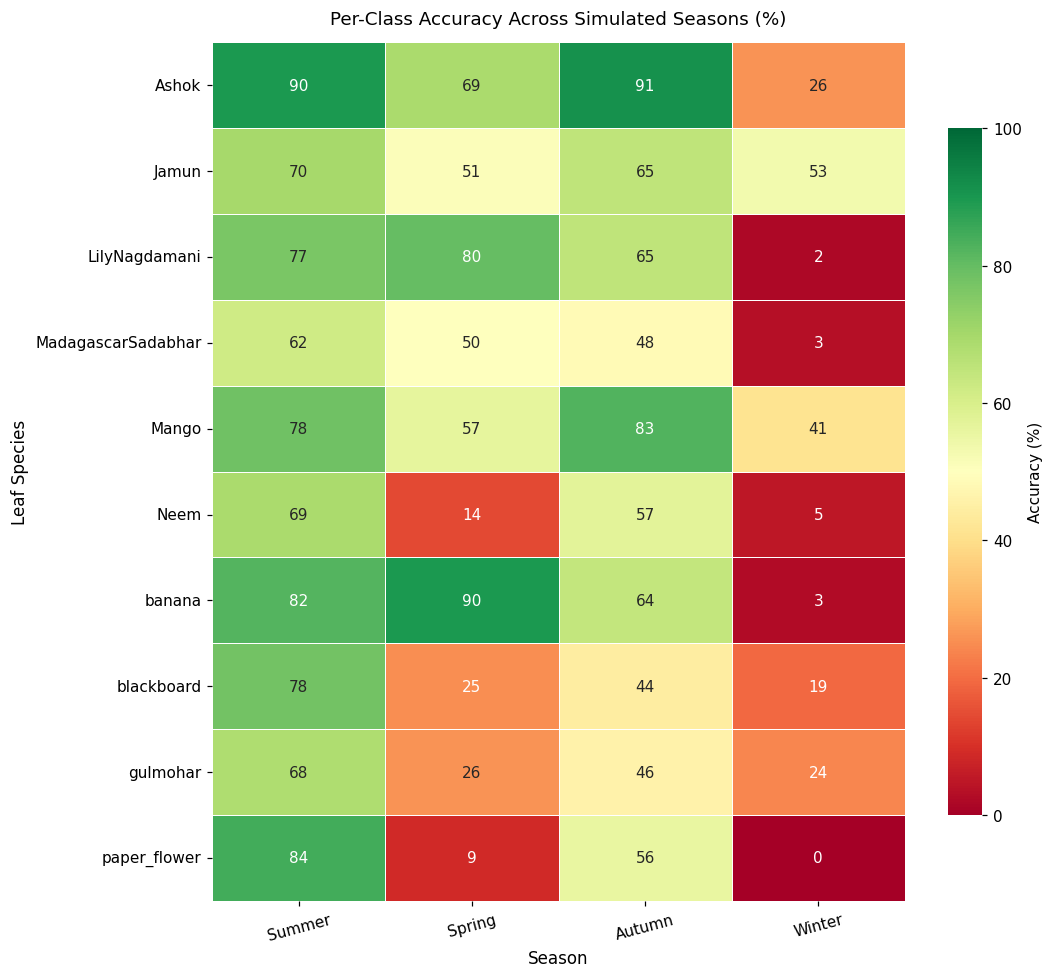

  Saved: per_class_season_heatmap.png

  Most robust species (least accuracy drop across seasons):
    Jamun                                     max drop: 18.6%
    Mango                                     max drop: 37.0%
    gulmohar                                  max drop: 44.0%

  Most affected species:
    paper_flower                              max drop: 84.4%
    banana                                    max drop: 79.5%
    LilyNagdamani                             max drop: 75.0%


In [30]:
# Build matrix: rows=classes, cols=seasons
short_seasons = [n.split('(')[0].strip() for n in season_results.keys()]
matrix = np.zeros((NUM_CLASSES, len(season_results)))

for col, season_name in enumerate(season_results.keys()):
    for row, cls_name in enumerate(CLASS_NAMES):
        matrix[row, col] = season_per_class[season_name].get(cls_name, 0) * 100

fig, ax = plt.subplots(figsize=(max(8, len(season_results)*2.5),
                                 max(5, NUM_CLASSES * 0.7 + 2)))

sns.heatmap(
    matrix,
    annot=True, fmt='.0f', cmap='RdYlGn',
    xticklabels=short_seasons,
    yticklabels=CLASS_NAMES,
    vmin=0, vmax=100,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Per-Class Accuracy Across Simulated Seasons (%)',
             fontsize=12, pad=12)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Leaf Species', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_season_heatmap.png'), dpi=150)
plt.show()
print('  Saved: per_class_season_heatmap.png')
print()
print('  Most robust species (least accuracy drop across seasons):')
drops = {}
baseline_col = 0  # Summer
for row, cls_name in enumerate(CLASS_NAMES):
    drop = matrix[row, baseline_col] - matrix[row, :].min()
    drops[cls_name] = drop
for cls, d in sorted(drops.items(), key=lambda x: x[1])[:3]:
    print(f'    {cls:<40}  max drop: {d:.1f}%')
print()
print('  Most affected species:')
for cls, d in sorted(drops.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f'    {cls:<40}  max drop: {d:.1f}%')

Step 9 — Confusion Matrices for Each Season

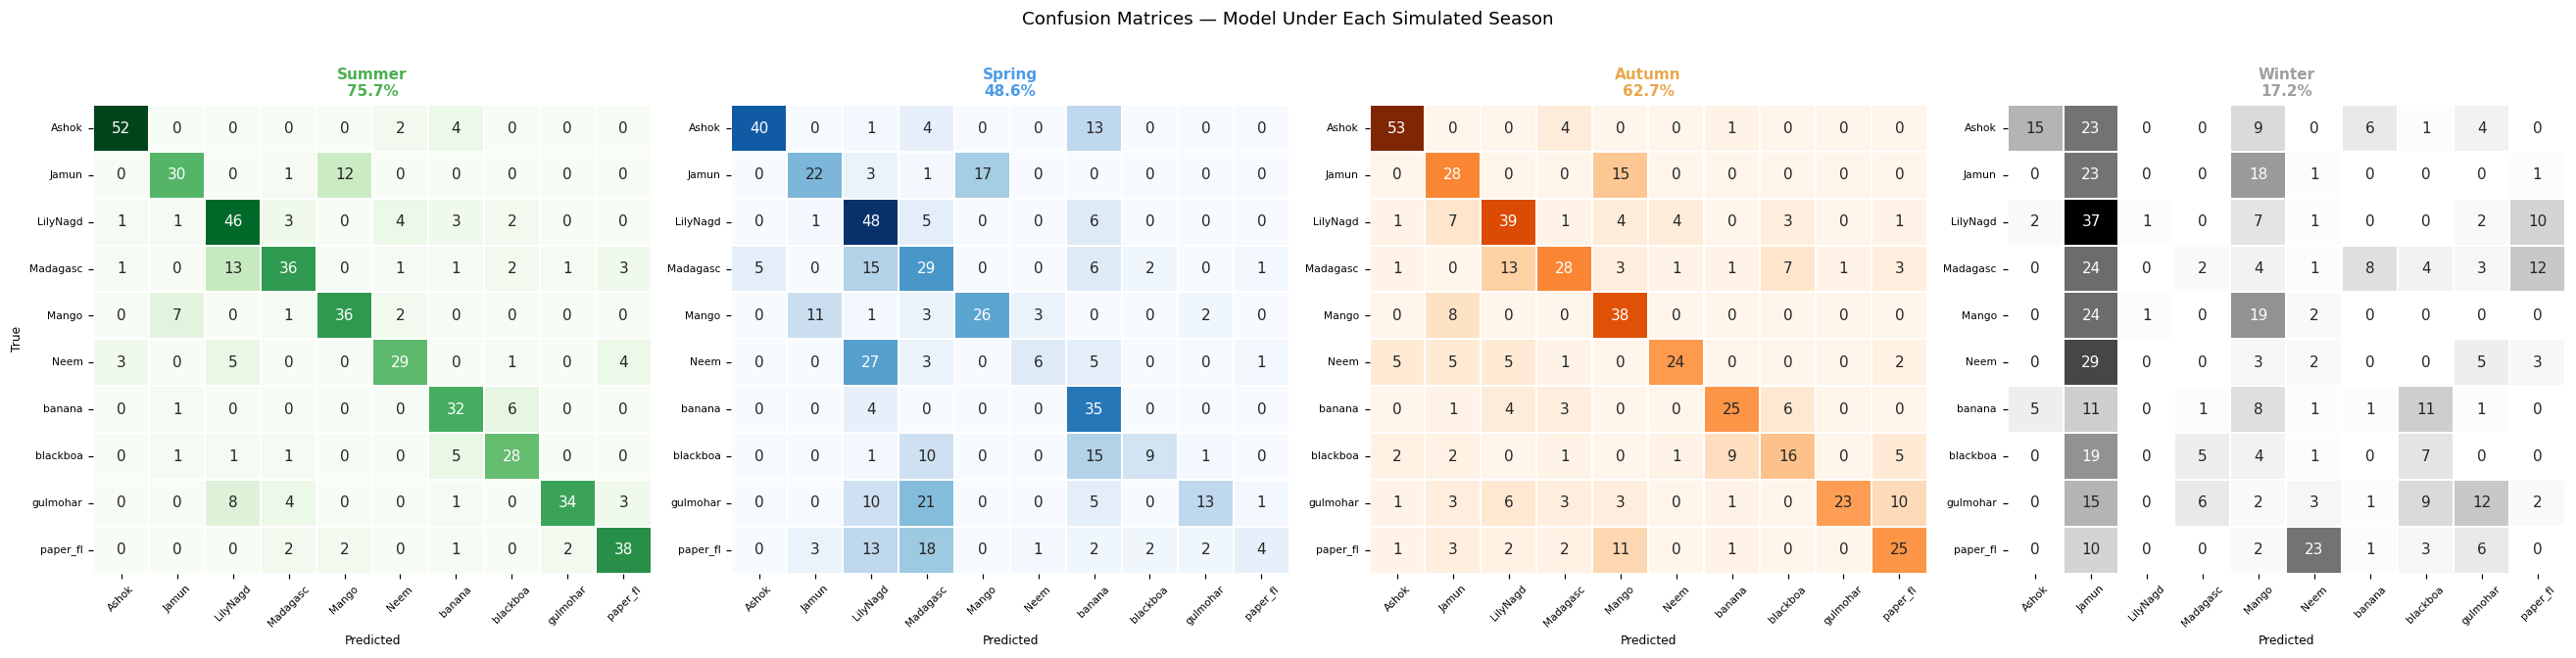

  Saved: season_confusion_matrices.png


In [31]:
n_seasons = len(season_results)
fig, axes = plt.subplots(1, n_seasons,
                          figsize=(n_seasons * max(5, NUM_CLASSES * 0.6), max(4, NUM_CLASSES * 0.6)))

if n_seasons == 1:
    axes = [axes]

cmaps = ['Greens', 'Blues', 'Oranges', 'Greys']

for idx, (season_name, (preds, labels)) in enumerate(season_reports.items()):
    cm   = confusion_matrix(labels, preds)
    acc  = season_results[season_name]
    ax   = axes[idx]

    sns.heatmap(cm, annot=(NUM_CLASSES <= 10), fmt='d',
                cmap=cmaps[idx % len(cmaps)],
                xticklabels=[c[:8] for c in CLASS_NAMES],
                yticklabels=[c[:8] for c in CLASS_NAMES],
                ax=ax, cbar=False,
                linewidths=0.3, linecolor='white')

    short = season_name.split('(')[0].strip()
    ax.set_title(f'{short}\n{acc*100:.1f}%', fontsize=10, fontweight='bold',
                 color=SEASON_COLORS[season_name])
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True' if idx == 0 else '', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle('Confusion Matrices — Model Under Each Simulated Season',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'season_confusion_matrices.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: season_confusion_matrices.png')

Step 11 — Classification Report Per Season

In [34]:
for season_name, (preds, labels) in season_reports.items():
    acc = season_results[season_name]
    print('='*65)
    print(f'  {season_name}   —   Accuracy: {acc*100:.2f}%')
    print('='*65)
    print(classification_report(labels, preds,
                                 target_names=CLASS_NAMES, digits=3))
    print()

  Summer (baseline)   —   Accuracy: 75.68%
                    precision    recall  f1-score   support

             Ashok      0.912     0.897     0.904        58
             Jamun      0.750     0.698     0.723        43
     LilyNagdamani      0.630     0.767     0.692        60
MadagascarSadabhar      0.750     0.621     0.679        58
             Mango      0.720     0.783     0.750        46
              Neem      0.763     0.690     0.725        42
            banana      0.681     0.821     0.744        39
        blackboard      0.718     0.778     0.747        36
          gulmohar      0.919     0.680     0.782        50
      paper_flower      0.792     0.844     0.817        45

          accuracy                          0.757       477
         macro avg      0.763     0.758     0.756       477
      weighted avg      0.766     0.757     0.757       477


  Spring (sharp + high contrast)   —   Accuracy: 48.64%
                    precision    recall  f1-score   suppo

## Cell 13 — Save & Download All Results

In [36]:
import zipfile

zip_path = '/kaggle/working/mini_project_1_results.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in os.listdir(OUTPUT_DIR):
        fpath = os.path.join(OUTPUT_DIR, f)
        z.write(fpath, f'outputs/{f}')
    for f in os.listdir(CHECKPOINT_DIR):
        fpath = os.path.join(CHECKPOINT_DIR, f)
        z.write(fpath, f'checkpoints/{f}')

print('  ✅ All files saved to /kaggle/working/mini_project_1_results.zip')
print()
print('  Output files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'    outputs/{f:<45} {size/1024:>7.1f} KB')
print()
print('  Checkpoint files:')
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    size = os.path.getsize(os.path.join(CHECKPOINT_DIR, f))
    print(f'    checkpoints/{f:<42} {size/1024/1024:>7.2f} MB')
print()
print('  ─────────────────────────────────────────────────────────')
print('  To download: Click the folder icon in the right panel →')
print('  /kaggle/working/ → right-click the .zip → Download')
print('  ─────────────────────────────────────────────────────────')

  ✅ All files saved to /kaggle/working/mini_project_1_results.zip

  Output files:
    outputs/confusion_matrix.png                            115.8 KB
    outputs/cross_season_accuracy.png                        56.3 KB
    outputs/cross_season_comment.txt                          3.5 KB
    outputs/exp_a_fewshot.png                                52.9 KB
    outputs/finetune_curves.png                              86.4 KB
    outputs/per_class_season_heatmap.png                    104.2 KB
    outputs/raw_distribution.png                             70.2 KB
    outputs/sample_images.png                              2057.5 KB
    outputs/season_confusion_matrices.png                   188.2 KB
    outputs/season_radar_chart.png                          243.4 KB
    outputs/season_visual_comparison.png                    816.2 KB
    outputs/ssl_loss.png                                     31.0 KB

  Checkpoint files:
    checkpoints/finetuned.pth                                43.21 M

Save All Output To Zip

In [37]:
import zipfile

bonus_zip = '/kaggle/working/bonus_cross_season_results.zip'
bonus_files = [
    'season_visual_comparison.png',
    'cross_season_accuracy.png',
    'per_class_season_heatmap.png',
    'season_confusion_matrices.png',
    'season_radar_chart.png',
    'cross_season_comment.txt',
]

with zipfile.ZipFile(bonus_zip, 'w', zipfile.ZIP_DEFLATED) as z:
    for fname in bonus_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if Path(fpath).exists():
            z.write(fpath, f'bonus/{fname}')
            size = os.path.getsize(fpath)
            print(f'  bonus/{fname:<45} {size/1024:>7.1f} KB')

print(f'\n  ZIP saved: {bonus_zip}')
print()
print('  ─────────────────────────────────────────────────────────')
print('  Download: File panel (right) → /kaggle/working/ → right-click zip → Download')
print('  ─────────────────────────────────────────────────────────')

  bonus/season_visual_comparison.png                    816.2 KB
  bonus/cross_season_accuracy.png                        56.3 KB
  bonus/per_class_season_heatmap.png                    104.2 KB
  bonus/season_confusion_matrices.png                   188.2 KB
  bonus/season_radar_chart.png                          243.4 KB
  bonus/cross_season_comment.txt                          3.5 KB

  ZIP saved: /kaggle/working/bonus_cross_season_results.zip

  ─────────────────────────────────────────────────────────
  Download: File panel (right) → /kaggle/working/ → right-click zip → Download
  ─────────────────────────────────────────────────────────
